In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/llm-benchmark-wars-2025-2026-24-models-compared/llm_benchmark_comparison_2025_2026.csv



# 🚀**Figuring out which LLM is best for students for *code-reviewing* purposes.**

## **Approach: Exploratory Data Analysis (EDA)** <br>
Six practices of EDA includes:
- Discovering
- Structuring
- Cleaning
- Joining
- Validating
- Presenting

## **Dataset used for EDA:** 
#### LLM-Benchmark-Comparison kaggle dataset

#### ***Preparing the data:***

In [2]:
#import necessary libs and load the dataset:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/alitaqishah/llm-benchmark-wars-2025-2026-24-models-compared/llm_benchmark_comparison_2025_2026.csv")

- ***Discovering***

In [3]:
#start by discovering the columns:
df.head(3)

,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,open_source,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
0,1,GPT-5.2,OpenAI,USA,2025,9,Proprietary,Transformer,Multimodal,False,...,0.85,False,True,"Speed, real-time apps, chatbots",Proprietary,90.30,53.41,Fast,Mid-range,Large
1,2,GPT-5.3 Codex,OpenAI,USA,2025,11,Proprietary,Transformer,Text+Code,False,...,1.10,True,False,"Code generation, software engineering",Proprietary,88.62,31.64,Medium,Mid-range,Extended
2,3,Gemini 3.1 Pro,Google DeepMind,USA,2025,10,Proprietary,Transformer,Multimodal,False,...,0.72,False,True,"Long context, multimodal, GPQA leader",Proprietary,90.22,73.81,Medium,Mid-range,Massive


**A quick columns detail:**   *(generated by Grok)*
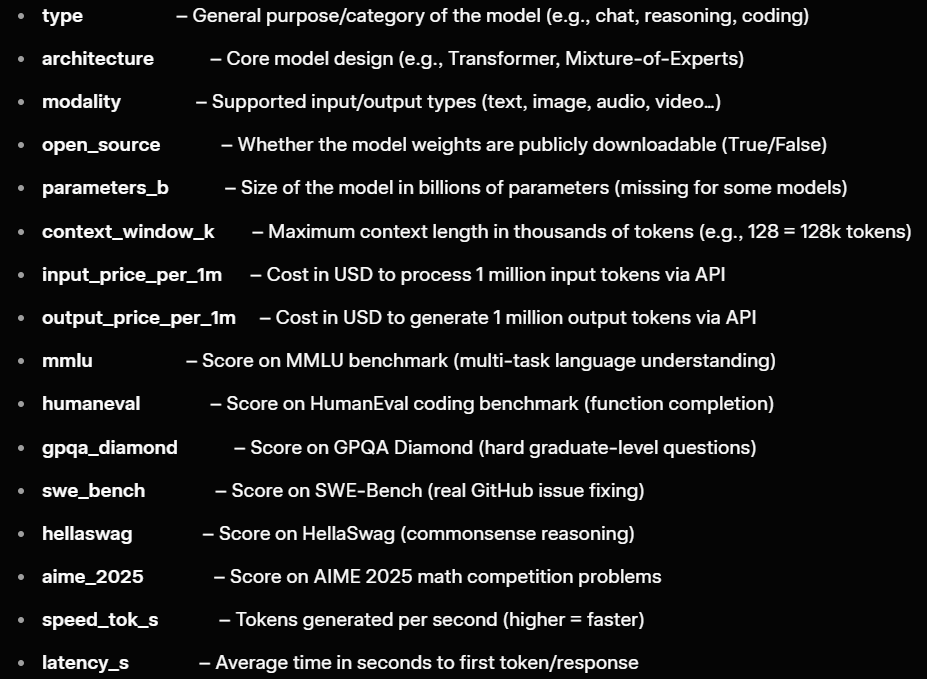
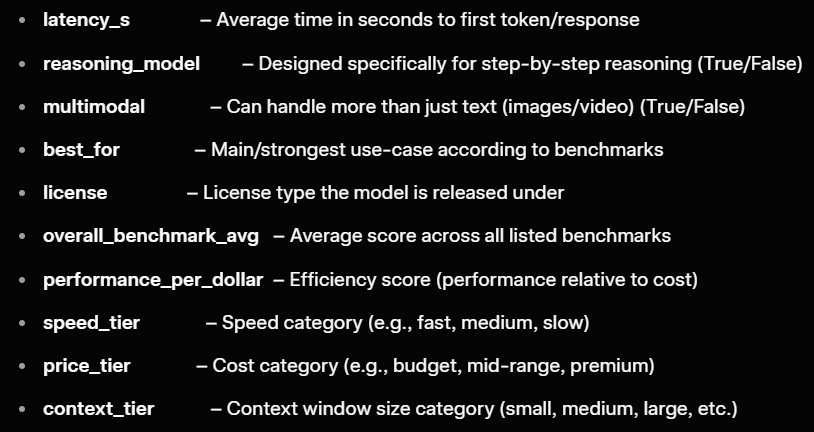

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank                    24 non-null     int64  
 1   model_name              24 non-null     object 
 2   organization            24 non-null     object 
 3   country                 24 non-null     object 
 4   release_year            24 non-null     int64  
 5   release_month           24 non-null     int64  
 6   type                    24 non-null     object 
 7   architecture            24 non-null     object 
 8   modality                24 non-null     object 
 9   open_source             24 non-null     bool   
 10  parameters_b            10 non-null     float64
 11  context_window_k        24 non-null     int64  
 12  input_price_per_1m      24 non-null     float64
 13  output_price_per_1m     24 non-null     float64
 14  mmlu                    24 non-null     floa

In [5]:
df.shape

(24, 31)

In [6]:
df.describe()

,rank,release_year,release_month,parameters_b,context_window_k,input_price_per_1m,output_price_per_1m,mmlu,humaneval,gpqa_diamond,swe_bench,hellaswag,aime_2025,speed_tok_s,latency_s,overall_benchmark_avg,performance_per_dollar
count,24.000000,24.000000,24.000000,10.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,2024.916667,6.125000,215.000000,832.666667,2.556875,12.041667,87.104167,90.008333,73.275000,61.720833,95.333333,78.950000,136.166667,0.736250,78.025833,1380.434167
std,7.071068,0.282330,2.802367,265.809038,2031.795836,4.367049,21.329776,5.814785,6.320836,16.203898,18.272930,2.919599,18.550495,91.828132,0.638264,11.096513,2925.126831
min,1.000000,2024.000000,1.000000,4.000000,32.000000,0.000000,0.000000,68.200000,70.100000,35.400000,18.200000,85.300000,28.400000,38.000000,0.180000,47.980000,6.140000
25%,6.750000,2025.000000,4.000000,34.000000,128.000000,0.131250,0.390000,86.225000,88.400000,63.675000,49.125000,95.025000,71.075000,84.000000,0.395000,72.635000,34.640000
50%,12.500000,2025.000000,5.500000,90.500000,200.000000,0.800000,3.600000,88.500000,91.300000,74.900000,63.850000,95.950000,80.050000,107.500000,0.565000,79.500000,107.040000
75%,18.250000,2025.000000,8.000000,330.750000,550.000000,2.625000,14.250000,90.050000,93.675000,87.850000,77.600000,96.950000,93.475000,152.750000,0.752500,86.712500,665.920000
max,24.000000,2025.000000,12.000000,671.000000,10000.000000,15.000000,75.000000,93.000000,97.500000,94.300000,83.000000,98.400000,100.000000,387.000000,3.200000,90.300000,9015.000000


In [7]:
#exploring the patterns or trends in the data:
df['country'].value_counts()

country
USA       17
China      5
France     2
Name: count, dtype: int64

In [8]:
df['release_year'].value_counts()

release_year
2025    22
2024     2
Name: count, dtype: int64

In [9]:
df['price_tier'].value_counts()

price_tier
Mid-range           8
Budget              7
Free/Ultra-cheap    6
Premium             3
Name: count, dtype: int64

In [10]:
llm_2024 = df['release_year']==2024
df[ llm_2024 ]

,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,open_source,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
15,16,GPT-4o,OpenAI,USA,2024,5,Proprietary,Transformer,Multimodal,False,...,0.35,False,True,"General use, fast responses, audio/vision",Proprietary,70.35,35.64,Ultra-Fast,Mid-range,Extended
20,21,Llama 3.3 70B,Meta,USA,2024,12,Open Source,Transformer,Text,True,...,0.45,False,False,"Local deployment, research, NLP tasks",Llama 3.3 Community License,68.70,8720.00,Medium,Free/Ultra-cheap,Extended


Text(0.5, 1.0, 'Countries Leading LLM Development 2024-2025')

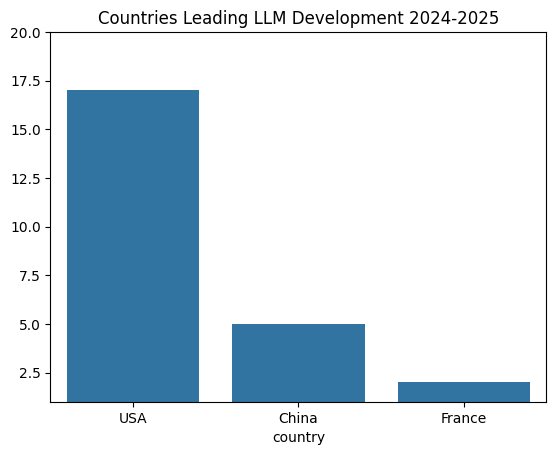

In [11]:
#key visualization:

country_models = df['country'].value_counts() # <- is a series

sns.barplot( x= country_models.index , y= country_models.values)
plt.ylim(1, 20)
plt.title("Countries Leading LLM Development 2024-2025")

***key findings:***
- most of the LLMs are from **USA** while rest are from **China** and **France**.
- majority models are released in year **2025**, only 2 are from **2024**.

- ***Cleaning*** & ***Input validation***

In [12]:
#only 'parameters_b' have null values, checking for any reason behind that:
null_rows =df['parameters_b'].isnull()
df[ null_rows ]

,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,open_source,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
0,1,GPT-5.2,OpenAI,USA,2025,9,Proprietary,Transformer,Multimodal,False,...,0.85,False,True,"Speed, real-time apps, chatbots",Proprietary,90.30,53.41,Fast,Mid-range,Large
1,2,GPT-5.3 Codex,OpenAI,USA,2025,11,Proprietary,Transformer,Text+Code,False,...,1.10,True,False,"Code generation, software engineering",Proprietary,88.62,31.64,Medium,Mid-range,Extended
2,3,Gemini 3.1 Pro,Google DeepMind,USA,2025,10,Proprietary,Transformer,Multimodal,False,...,0.72,False,True,"Long context, multimodal, GPQA leader",Proprietary,90.22,73.81,Medium,Mid-range,Massive
3,4,Claude Opus 4.6,Anthropic,USA,2025,8,Proprietary,Transformer,Multimodal,False,...,1.50,False,True,"Coding, reasoning, lowest hallucination rate",Proprietary,89.60,6.21,Medium,Premium,Extended
4,5,Claude Opus 4.5,Anthropic,USA,2025,5,Proprietary,Transformer,Multimodal,False,...,1.60,False,True,"SWE-bench leader, production code",Proprietary,88.82,6.14,Medium,Premium,Extended
5,6,o3,OpenAI,USA,2025,4,Proprietary,Transformer (Reasoning),Text,False,...,3.20,True,False,"Complex reasoning, math olympiad",Proprietary,86.90,9.40,Slow,Premium,Extended
7,8,Grok 4.1,xAI,USA,2025,7,Proprietary,Transformer,Multimodal,False,...,0.58,False,True,"Real-time web data, X integration",Proprietary,82.48,30.32,Fast,Mid-range,Massive
8,9,Gemini 2.5 Pro,Google DeepMind,USA,2025,3,Proprietary,Transformer,Multimodal,False,...,0.65,False,True,"Multimodal, document analysis, coding",Proprietary,86.65,72.02,Fast,Mid-range,Large
9,10,Claude Sonnet 4.6,Anthropic,USA,2025,8,Proprietary,Transformer,Multimodal,False,...,0.95,False,True,Balanced performance and cost,Proprietary,84.35,29.85,Medium,Mid-range,Extended
10,11,MiniMax-M2.5,MiniMax,China,2025,7,Proprietary,MoE,Text,False,...,0.72,False,False,"SWE-bench top tier, Chinese market",Proprietary,84.45,110.68,Medium,Budget,Extended


In [13]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
dtype: bool

In [14]:
#checking for duplicates in model_name:
set( df['model_name']) == df['model_name']

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
Name: model_name, dtype: bool

In [15]:
df.describe()

,rank,release_year,release_month,parameters_b,context_window_k,input_price_per_1m,output_price_per_1m,mmlu,humaneval,gpqa_diamond,swe_bench,hellaswag,aime_2025,speed_tok_s,latency_s,overall_benchmark_avg,performance_per_dollar
count,24.000000,24.000000,24.000000,10.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,12.500000,2024.916667,6.125000,215.000000,832.666667,2.556875,12.041667,87.104167,90.008333,73.275000,61.720833,95.333333,78.950000,136.166667,0.736250,78.025833,1380.434167
std,7.071068,0.282330,2.802367,265.809038,2031.795836,4.367049,21.329776,5.814785,6.320836,16.203898,18.272930,2.919599,18.550495,91.828132,0.638264,11.096513,2925.126831
min,1.000000,2024.000000,1.000000,4.000000,32.000000,0.000000,0.000000,68.200000,70.100000,35.400000,18.200000,85.300000,28.400000,38.000000,0.180000,47.980000,6.140000
25%,6.750000,2025.000000,4.000000,34.000000,128.000000,0.131250,0.390000,86.225000,88.400000,63.675000,49.125000,95.025000,71.075000,84.000000,0.395000,72.635000,34.640000
50%,12.500000,2025.000000,5.500000,90.500000,200.000000,0.800000,3.600000,88.500000,91.300000,74.900000,63.850000,95.950000,80.050000,107.500000,0.565000,79.500000,107.040000
75%,18.250000,2025.000000,8.000000,330.750000,550.000000,2.625000,14.250000,90.050000,93.675000,87.850000,77.600000,96.950000,93.475000,152.750000,0.752500,86.712500,665.920000
max,24.000000,2025.000000,12.000000,671.000000,10000.000000,15.000000,75.000000,93.000000,97.500000,94.300000,83.000000,98.400000,100.000000,387.000000,3.200000,90.300000,9015.000000


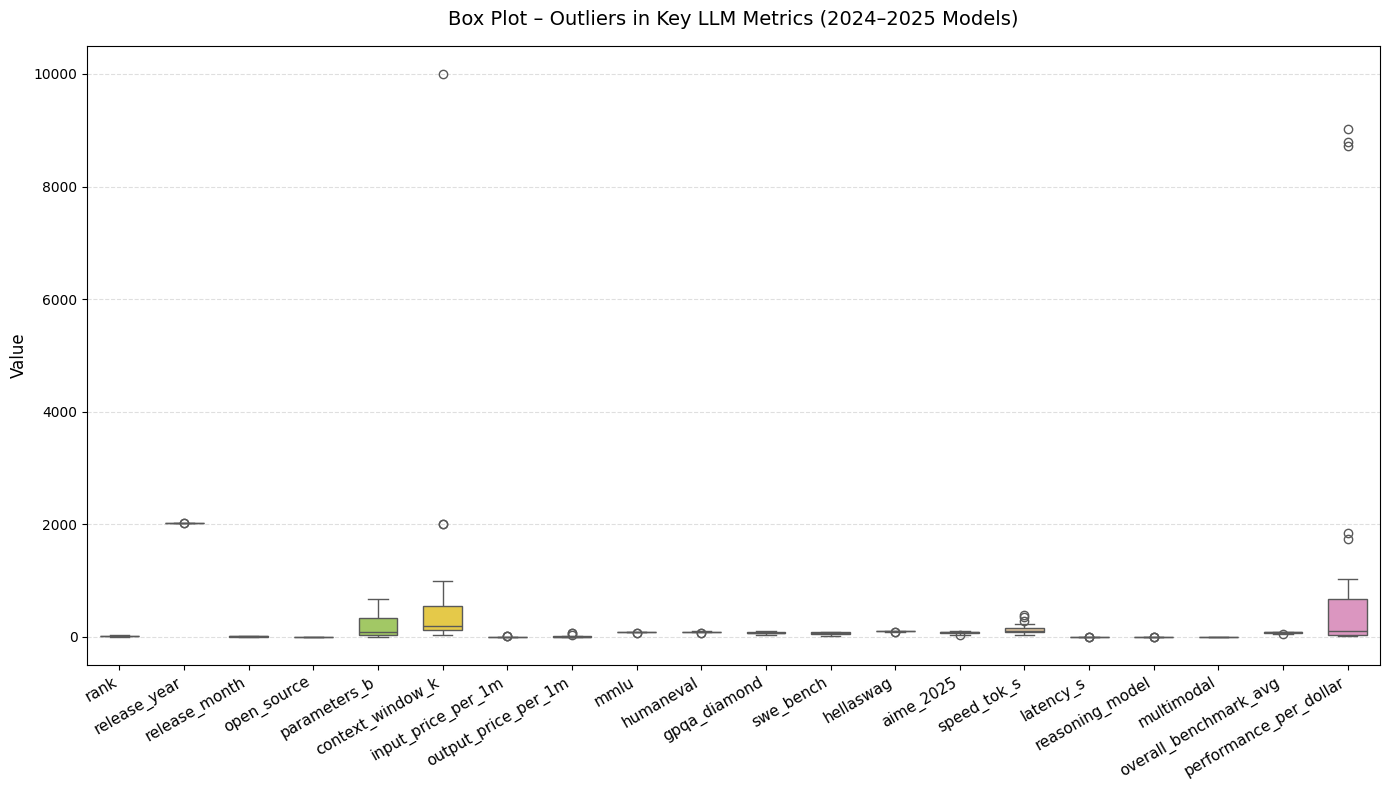

In [16]:
#key visualization for identifying outliers using IQR rule of thumb:  (coded by Grok 😊)

# Plot boxplots:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, palette='Set2', width=0.6)
plt.title("Box Plot – Outliers in Key LLM Metrics (2024–2025 Models)", fontsize=14, pad=15)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

***key findings:***

- only the "**parameters_b**" variable has null values.
- there is **no** duplicated row.
- there is **no** problematic misspellings.
- there are global outliers in: ***performance_per_dollar*** & ***context_widow_k*** affecting their mean values, but can be ignored in our analysis.

- ***Structuring*** & **Presenting**

In [17]:
#now get the best models for code reviewing by looking at their 'SWE benchmark':
best_models = df.sort_values( 'swe_bench',ascending=False).reset_index()
best_models


,index,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
0,1,2,GPT-5.3 Codex,OpenAI,USA,2025,11,Proprietary,Transformer,Text+Code,...,1.10,True,False,"Code generation, software engineering",Proprietary,88.62,31.64,Medium,Mid-range,Extended
1,4,5,Claude Opus 4.5,Anthropic,USA,2025,5,Proprietary,Transformer,Multimodal,...,1.60,False,True,"SWE-bench leader, production code",Proprietary,88.82,6.14,Medium,Premium,Extended
2,3,4,Claude Opus 4.6,Anthropic,USA,2025,8,Proprietary,Transformer,Multimodal,...,1.50,False,True,"Coding, reasoning, lowest hallucination rate",Proprietary,89.60,6.21,Medium,Premium,Extended
3,2,3,Gemini 3.1 Pro,Google DeepMind,USA,2025,10,Proprietary,Transformer,Multimodal,...,0.72,False,True,"Long context, multimodal, GPQA leader",Proprietary,90.22,73.81,Medium,Mid-range,Massive
4,10,11,MiniMax-M2.5,MiniMax,China,2025,7,Proprietary,MoE,Text,...,0.72,False,False,"SWE-bench top tier, Chinese market",Proprietary,84.45,110.68,Medium,Budget,Extended
5,0,1,GPT-5.2,OpenAI,USA,2025,9,Proprietary,Transformer,Multimodal,...,0.85,False,True,"Speed, real-time apps, chatbots",Proprietary,90.30,53.41,Fast,Mid-range,Large
6,8,9,Gemini 2.5 Pro,Google DeepMind,USA,2025,3,Proprietary,Transformer,Multimodal,...,0.65,False,True,"Multimodal, document analysis, coding",Proprietary,86.65,72.02,Fast,Mid-range,Large
7,6,7,Qwen3.5 Plus,Alibaba,China,2025,9,Open Weight,Transformer,Text,...,0.55,False,False,"Coding, LiveCodeBench leader, multilingual",Qwen License,86.40,177.16,Medium,Budget,Extended
8,12,13,DeepSeek V3.2,DeepSeek,China,2025,6,Open Source,MoE,Text,...,0.31,False,False,"Cost efficiency, 94% cheaper than Claude",DeepSeek License,80.45,310.86,Slow,Budget,Extended
9,9,10,Claude Sonnet 4.6,Anthropic,USA,2025,8,Proprietary,Transformer,Multimodal,...,0.95,False,True,Balanced performance and cost,Proprietary,84.35,29.85,Medium,Mid-range,Extended


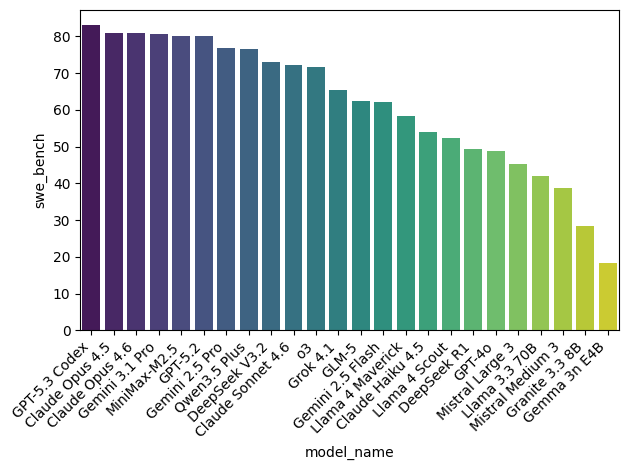

In [18]:
#swe benchmark visualization: 
sns.barplot(
    data=best_models,
    x='model_name',
    y='swe_bench',
    hue='model_name',          
    palette='viridis',
    legend=False       
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
#taking top 12 models:
best_12_models = best_models.head(12)
best_12_models['swe_bench']

0     83.0
1     80.9
2     80.8
3     80.6
4     80.2
5     80.0
6     76.8
7     76.5
8     73.1
9     72.3
10    71.7
11    65.3
Name: swe_bench, dtype: float64

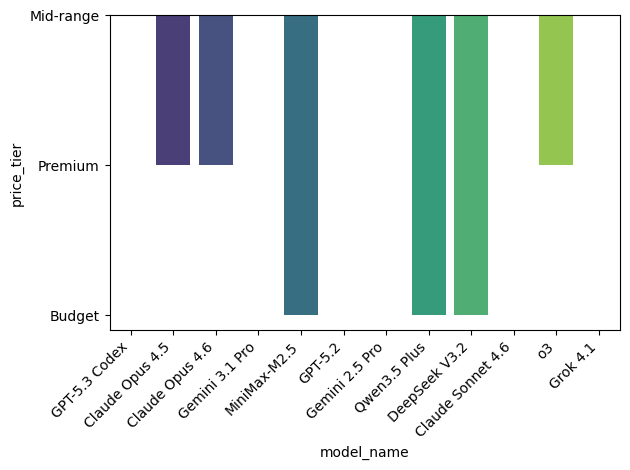

In [20]:
#price-wise visualization:
sns.barplot(
    data=best_12_models,
    x='model_name',
    y='price_tier',
    hue='model_name',           
    palette='viridis',
    legend=False                
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
#our final selected models for code reviewing:
best_budget_models = best_12_models[ best_12_models['price_tier']=='Budget']
best_budget_models

,index,rank,model_name,organization,country,release_year,release_month,type,architecture,modality,...,latency_s,reasoning_model,multimodal,best_for,license,overall_benchmark_avg,performance_per_dollar,speed_tier,price_tier,context_tier
4,10,11,MiniMax-M2.5,MiniMax,China,2025,7,Proprietary,MoE,Text,...,0.72,False,False,"SWE-bench top tier, Chinese market",Proprietary,84.45,110.68,Medium,Budget,Extended
7,6,7,Qwen3.5 Plus,Alibaba,China,2025,9,Open Weight,Transformer,Text,...,0.55,False,False,"Coding, LiveCodeBench leader, multilingual",Qwen License,86.40,177.16,Medium,Budget,Extended
8,12,13,DeepSeek V3.2,DeepSeek,China,2025,6,Open Source,MoE,Text,...,0.31,False,False,"Cost efficiency, 94% cheaper than Claude",DeepSeek License,80.45,310.86,Slow,Budget,Extended


***key findings:***
- **SWE benchmark** alone can tell us which model is best for 'code reviewing' purposes. Taking top 12 models from the barplot ,have SWE benchmark **>60**
- out of those 12 models, the budget friendly ones for a student are:
  - MinMax-M2.5
  - Qwen 3.5 plus
  - Deepseek V3.2 <br>
- **Note:** Budget = either on free-tier or minimum cost (for API access)

## **Conclusion:**
#### The best models for code-reviewing purposes, especially for students, are:
 - MinMax-M2.5
  - Qwen 3.5 plus
  - Deepseek V3.2
###### **Note:  In 2026 more efficient models are introduced. Above are in top 10 best models for code-reviewing students can still use**

💖 If you like the efforts, do star the GitHub repo ⭐ thanks :)